# Spacehopper Gripper Data Evaluation\nThis notebook processes the raw ROS logs from the physical gripper tests on various rock surfaces. It trims the initial offsets, identifies the point of slippage (when Tangential Force Fx drops), and plots the Maximum Normal Force (Fz) vs Tangential Force prior to slippage. The calculated statistics are then used to evaluate the gripper's holding performance.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
def plot_forces(df, cut_1=0, cut_2=None, avg_end=None, fx_threshold=1, offset_position='beginning', offset_length=10):
    """
    Plots the Tangential Force (Fx) and Normal Force (Fz) from the given DataFrame with offsets
    and within a specified range.

    Parameters:
    df (pd.DataFrame): The DataFrame containing force data with columns 'Fx' and 'Fz'.
    cut_1 (int): The starting index for the range of data to be plotted.
    cut_2 (int or None): The ending index for the range of data to be plotted. If None, plot till the end.

    Returns:
    None
    """
    if offset_position == 'beginning':
        # Calculate the offsets as the average of the first 20 entries
        offset_x = df['Fx'][:offset_length].mean()
        offset_z = df['Fz'][:offset_length].mean()
    elif offset_position == 'end':
        # Calculate the offsets as the average of the last 20 entries
        offset_x = df['Fx'][-offset_length:].mean()
        offset_z = df['Fz'][-offset_length:].mean()
    else:
        raise ValueError("Invalid offset_position. Choose either 'beginning' or 'end'.")

    # If avg_end is not provided, use cut_2
    avg_end = avg_end if avg_end is not None else cut_2

    # If avg_end is not None, calculate the length from cut_1 to avg_end
    if avg_end is not None and cut_1 is not None:
        length_cut_to_avg = avg_end - cut_1
        print(f"Length from cut_1 to avg_end: {length_cut_to_avg}")

    # Calculate average values of Fx and Fz in the defined averaging interval
    avg_fx = df[cut_1:avg_end]['Fx'].mean() - offset_x
    avg_fz = df[cut_1:avg_end]['Fz'].mean() - offset_z

    # Apply the cut range to the DataFrame
    df_cut = df[cut_1:cut_2].copy()
    
    # Find the maximum Fz and corresponding timestep
    max_fz = df_cut['Fz'].max() - offset_z
    max_fz_timestep = df_cut['Fz'].idxmax()

    # Find the timestep where Fx drops below the threshold
    fx_drop_timestep = df_cut[df_cut['Fx'] - offset_x < fx_threshold].index.min()
    
    # Print the average values
    print(f"Average Fx in the averaging interval [{cut_1}:{avg_end}]: {avg_fx}")
    print(f"Average Fz in the averaging interval [{cut_1}:{avg_end}]: {avg_fz}")
    print(f"Maximum Fz in the plotting interval [{cut_1}:{cut_2}]: {max_fz} at timestep {max_fz_timestep}")
    print(f"Time step where Fx drops below {fx_threshold}: {fx_drop_timestep}")
    
    plt.figure(figsize=(10, 5))
    plt.plot(df_cut['Fx'] - offset_x, label='Tangential Force (Fx)', alpha=0.7)
    plt.plot(df_cut['Fz'] - offset_z, label='Normal Force (Fz)', alpha=0.7)
    plt.axvline(x=max_fz_timestep, color='r', linestyle='--', label='Max Fz', alpha=0.2)
    plt.axvline(x=fx_drop_timestep, color='g', linestyle='--', label=f'Fx < {fx_threshold}', alpha=0.2)
    plt.xlabel('Timesteps')
    plt.ylabel('Force (N)')
    plt.legend()
    plt.title('Tangential vs Normal Force (Offset Adjusted)')
    plt.grid()
    plt.show()

    # Apply the offsets to the cut DataFrame
    df_cut['Fx'] = df_cut['Fx'] - offset_x
    df_cut['Fz'] = df_cut['Fz'] - offset_z
    
    # Shift the index so it starts at 0 if cut_1 is not None
    if cut_1 is not None:
        df_cut.index = df_cut.index - cut_1

    # Return the modified DataFrame
    return df_cut, (length_cut_to_avg if avg_end is not None and cut_1 is not None else None)

<font size="6">MatrixBrekzie 70°</font>

<font size="6">Test 1: (worked)</font>

Length from cut_1 to avg_end: 706
Average Fx in the averaging interval [890:1596]: 5.521694079967351
Average Fz in the averaging interval [890:1596]: 0.680886169375959
Maximum Fz in the plotting interval [890:None]: 1.7811360677083334 at timestep 1419
Time step where Fx drops below 1: 1596


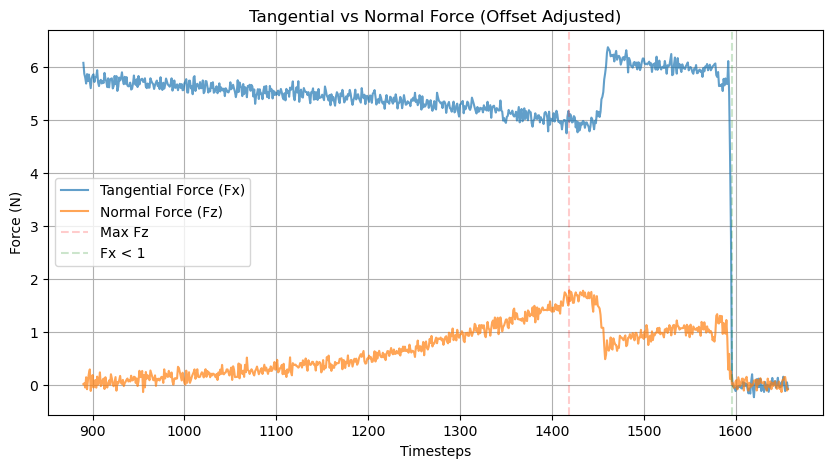

In [3]:
data = "../raw_data/Gripper Test Microspines Angles//MatrixBrekzie_70_5N//log_202405232011.csv"
df = pd.read_csv(data)
test_1, end_1 = plot_forces(df, cut_1=890, cut_2=None, avg_end=1596, offset_position='end', offset_length=15)

<font size="6">Test 2: (worked)</font>

Length from cut_1 to avg_end: 554
Average Fx in the averaging interval [600:1154]: 5.240060575602287
Average Fz in the averaging interval [600:1154]: 0.7190037108787417
Maximum Fz in the plotting interval [600:None]: 1.7255330403645834 at timestep 1102
Time step where Fx drops below 1: 1154


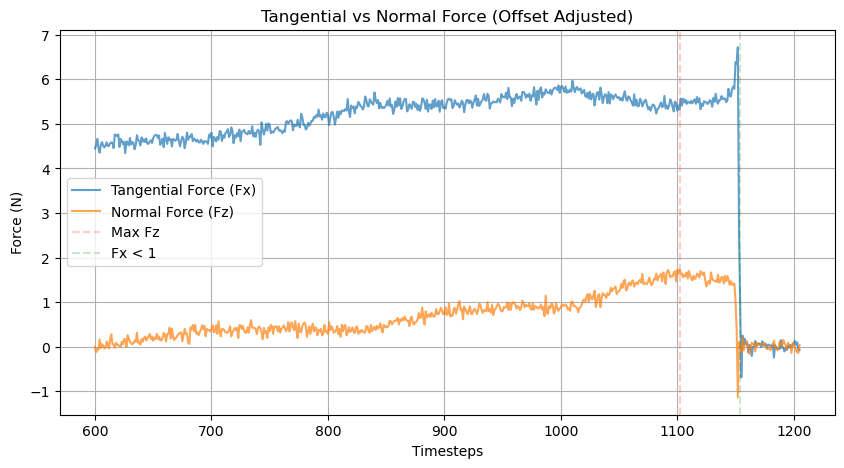

In [4]:
data = "../raw_data/Gripper Test Microspines Angles//MatrixBrekzie_70_5N//log_202405232012.csv"
df = pd.read_csv(data)
test_2, end_2 = plot_forces(df, cut_1=600, cut_2=None, avg_end=1154, offset_position='end', offset_length=15)

<font size="6">Test 3: (worked)</font>

Length from cut_1 to avg_end: 180
Average Fx in the averaging interval [780:960]: 4.536264207628038
Average Fz in the averaging interval [780:960]: 0.24874776204427085
Maximum Fz in the plotting interval [780:None]: 0.9489217122395833 at timestep 942
Time step where Fx drops below 1: 960


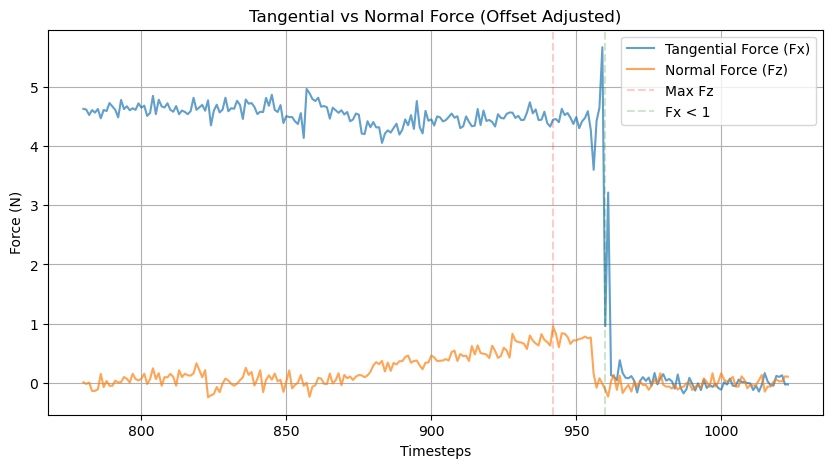

In [5]:
data = "../raw_data/Gripper Test Microspines Angles//MatrixBrekzie_70_5N//log_202405232013.csv"
df = pd.read_csv(data)
test_3, end_3 = plot_forces(df, cut_1=780, cut_2=None, avg_end=960, offset_position='end', offset_length=15)

<font size="6">Test 4: (worked)</font>

Length from cut_1 to avg_end: 409
Average Fx in the averaging interval [800:1209]: 4.813965114229757
Average Fz in the averaging interval [800:1209]: 0.1593089407599837
Maximum Fz in the plotting interval [800:None]: 0.9561482747395833 at timestep 1170
Time step where Fx drops below 1: 1209


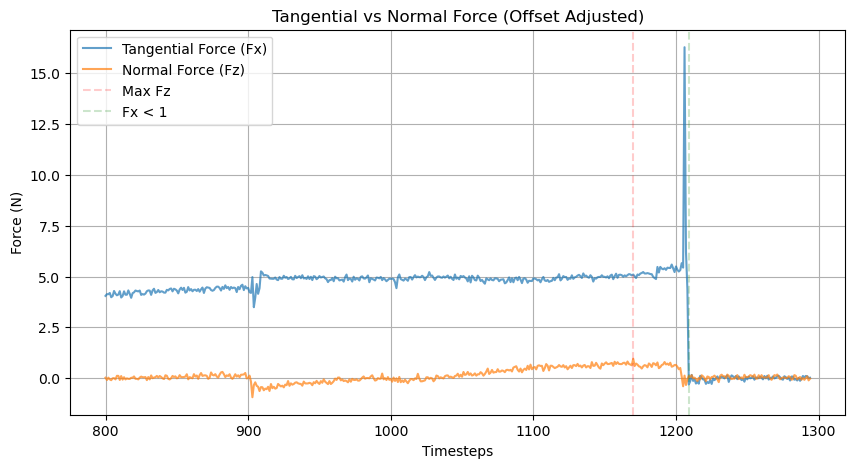

In [6]:
data = "../raw_data/Gripper Test Microspines Angles//MatrixBrekzie_70_5N//log_202405232014.csv"
df = pd.read_csv(data)
test_4, end_4 = plot_forces(df, cut_1=800, cut_2=None, avg_end=1209, offset_position='end', offset_length=15)

<font size="6">Test 5: (worked)</font>

Length from cut_1 to avg_end: 254
Average Fx in the averaging interval [625:879]: 5.22641720696697
Average Fz in the averaging interval [625:879]: 0.137501922367126
Maximum Fz in the plotting interval [625:930]: 0.58592529296875 at timestep 858
Time step where Fx drops below 1: 879


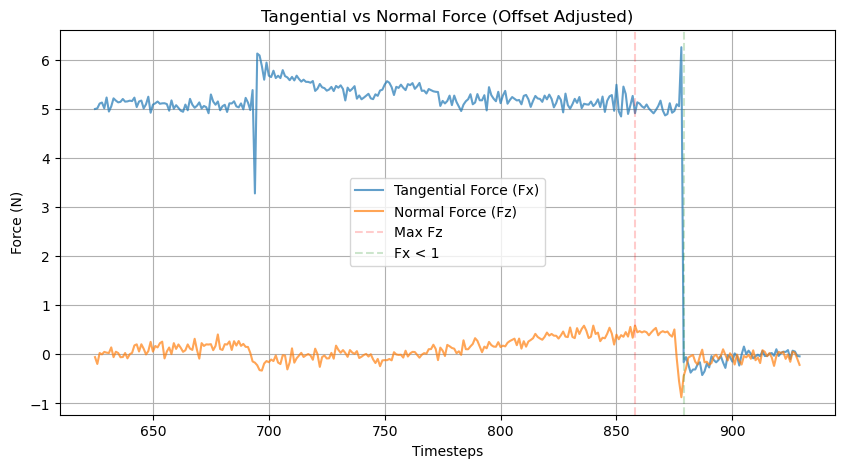

In [7]:
data = "../raw_data/Gripper Test Microspines Angles//MatrixBrekzie_70_5N//log_202405232017.csv"
df = pd.read_csv(data)
test_5, end_5 = plot_forces(df, cut_1=625, cut_2=930, avg_end=879, offset_position='beginning', offset_length=15)

<font size="6">Test 6: (failed)</font>

Average Fx in the averaging interval [None:None]: 4.354178944771033
Average Fz in the averaging interval [None:None]: -1.593631982345564
Maximum Fz in the plotting interval [None:None]: 0.42069905598958335 at timestep 1300
Time step where Fx drops below 1: 0


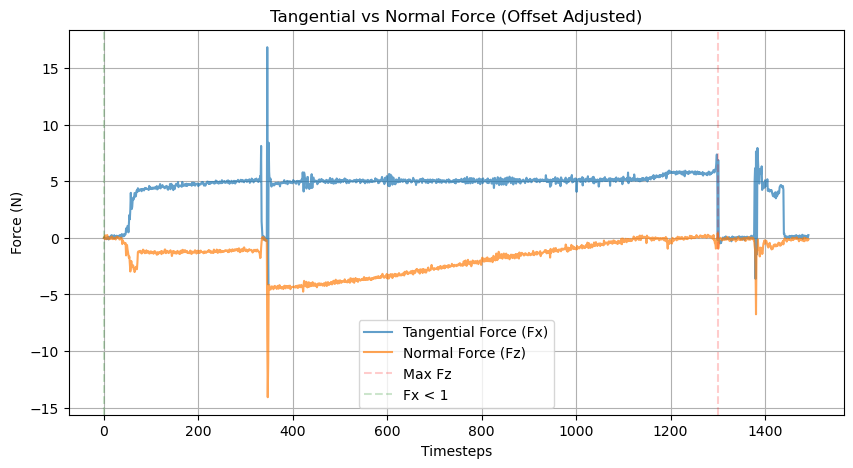

In [8]:
data = "../raw_data/Gripper Test Microspines Angles//MatrixBrekzie_70_5N//log_202405232018.csv"
df = pd.read_csv(data)
test_6, end_6 = plot_forces(df, cut_1=None, cut_2=None, avg_end=None, offset_position='beginning', offset_length=15)

<font size="6">Test 7: (worked)</font>

Length from cut_1 to avg_end: 1099
Average Fx in the averaging interval [660:1759]: 5.492699449699432
Average Fz in the averaging interval [660:1759]: 1.712665789034065
Maximum Fz in the plotting interval [660:None]: 3.65572509765625 at timestep 1747
Time step where Fx drops below 1: 1759


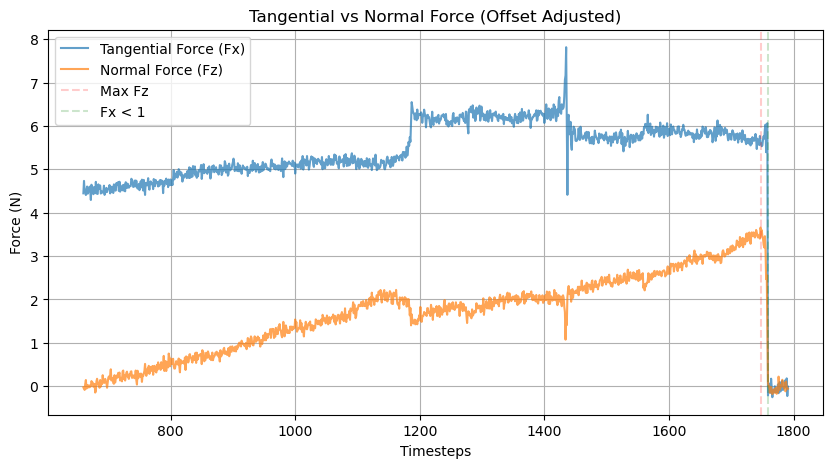

In [9]:
data = "../raw_data/Gripper Test Microspines Angles//MatrixBrekzie_70_5N//log_202405232019.csv"
df = pd.read_csv(data)
test_7, end_7 = plot_forces(df, cut_1=660, cut_2=None, avg_end=1759, offset_position='end', offset_length=15)

<font size="6">Test 8: (worked)</font>

Length from cut_1 to avg_end: 628
Average Fx in the averaging interval [840:1468]: 5.088253336955028
Average Fz in the averaging interval [840:1468]: 0.8400559346387341
Maximum Fz in the plotting interval [840:None]: 2.81502685546875 at timestep 1469
Time step where Fx drops below 1: 1468


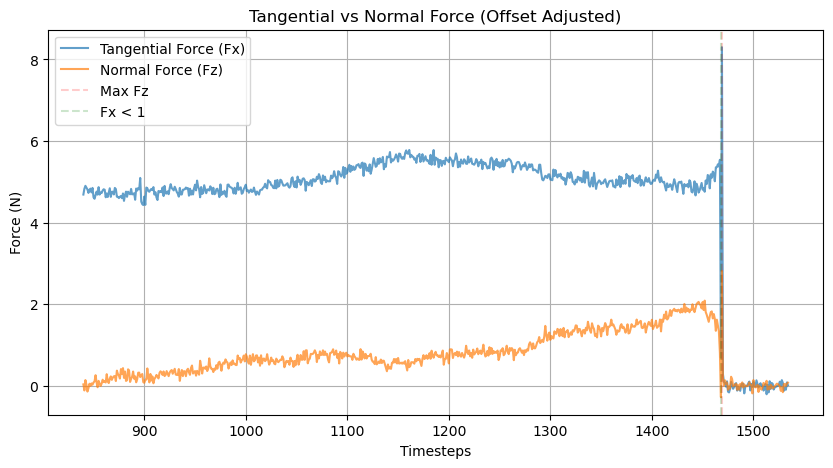

In [10]:
data = "../raw_data/Gripper Test Microspines Angles//MatrixBrekzie_70_5N//log_202405232021.csv"
df = pd.read_csv(data)
test_8, end_8 = plot_forces(df, cut_1=840, cut_2=None, avg_end=1468, offset_position='end', offset_length=15)

<font size="6">Test 9: (worked)</font>

Length from cut_1 to avg_end: 1147
Average Fx in the averaging interval [645:1792]: 4.554076071653004
Average Fz in the averaging interval [645:1792]: 1.787057417958533
Maximum Fz in the plotting interval [645:None]: 3.36644287109375 at timestep 1704
Time step where Fx drops below 0.5: 1792


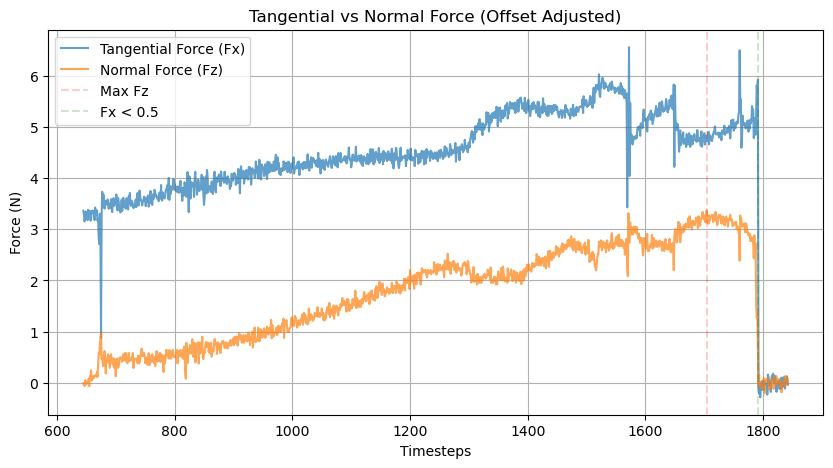

In [11]:
data = "../raw_data/Gripper Test Microspines Angles//MatrixBrekzie_70_5N//log_202405232022.csv"
df = pd.read_csv(data)
test_9, end_9 = plot_forces(df, cut_1=645, cut_2=None, avg_end=1792, offset_position='end', offset_length=15, fx_threshold=0.5)

<font size="6">Test 10: (worked)</font>

Length from cut_1 to avg_end: 739
Average Fx in the averaging interval [890:1629]: 5.380458143395134
Average Fz in the averaging interval [890:1629]: 1.765234672329584
Maximum Fz in the plotting interval [890:None]: 2.8447265625 at timestep 1439
Time step where Fx drops below 1: 1629


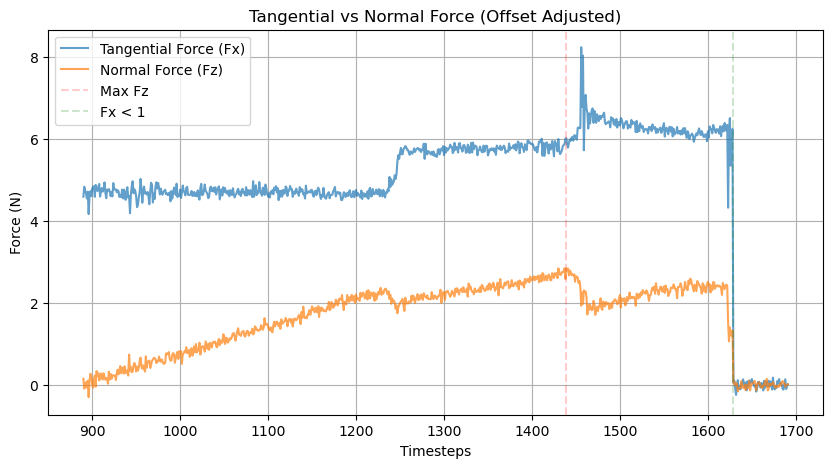

In [12]:
data = "../raw_data/Gripper Test Microspines Angles//MatrixBrekzie_70_5N//log_202405232023.csv"
df = pd.read_csv(data)
test_10, end_10 = plot_forces(df, cut_1=890, cut_2=None, avg_end=1629, offset_position='end', offset_length=15)

In [13]:
def plot_multiple_tests(tests, ends):
    # Find the maximum length among all datasets
    max_length = max([end for end in ends if end is not None])
    
    plt.figure(figsize=(15, 7))
    
    for i, (test, end) in enumerate(zip(tests, ends)):
        if end is not None:
            fz_series = test['Fz']
            fz_series_cut = fz_series[:end]
            if len(fz_series_cut) < max_length:
                padded_fz = np.pad(fz_series_cut.values, (0, max_length - len(fz_series_cut)), 'constant', constant_values=np.nan)
            else:
                padded_fz = fz_series_cut.values
            plt.plot(padded_fz, label=f'Dataset {i+1} Fz', alpha=0.6)
        
    plt.xlabel('Adjusted Timesteps')
    plt.ylabel('Normal Force (Fz) (N)')
    plt.legend()
    plt.title('Normal Force (Fz) of Multiple Datasets')
    plt.grid()
    plt.show()

In [17]:
def calculate_statistics(tests, ends):
    max_fz_values = []
    avg_fz_values = []
    avg_fx_values = []
    
    for test, end in zip(tests, ends):
        if end is not None:
            fz_series = test['Fz']
            fx_series = test['Fx']
            fz_series_cut = fz_series[:end]
            fx_series_cut = fx_series[:end]
            max_fz_values.append(fz_series_cut.max())
            avg_fz_values.append(fz_series_cut.mean())
            avg_fx_values.append(fx_series_cut.mean())
    
    average_max_fz = np.mean(max_fz_values)
    std_max_fz = np.std(max_fz_values)
    
    average_avg_fz = np.mean(avg_fz_values)
    std_avg_fz = np.std(avg_fz_values)
    
    average_avg_fx = np.mean(avg_fx_values)
    std_avg_fx = np.std(avg_fx_values)
    
    print(f"Average of maximum Fz forces: {average_max_fz}")
    print(f"Standard deviation of maximum Fz forces: {std_max_fz}")
    print(f"Average of average Fz forces: {average_avg_fz}")
    print(f"Standard deviation of average Fz forces: {std_avg_fz}")
    print(f"Average of average Fx forces: {average_avg_fx}")
    print(f"Standard deviation of average Fx forces: {std_avg_fx}")
    
    # Create a dictionary to store the statistics
    statistics_dict = {
        'Statistic': ['Average Max Fz', 'Std Max Fz', 'Average Avg Fz', 'Std Avg Fz', 'Average Avg Fx', 'Std Avg Fx'],
        'Value': [average_max_fz, std_max_fz, average_avg_fz, std_avg_fz, average_avg_fx, std_avg_fx]
    }
    
    # Convert the dictionary to a DataFrame
    statistics_df = pd.DataFrame(statistics_dict)
    
    # Save the statistics to a CSV file
    statistics_df.to_csv("../raw_data/Gripper Test Microspines Angles//70//MatrixBrekzie_70_stats.csv", index=False)

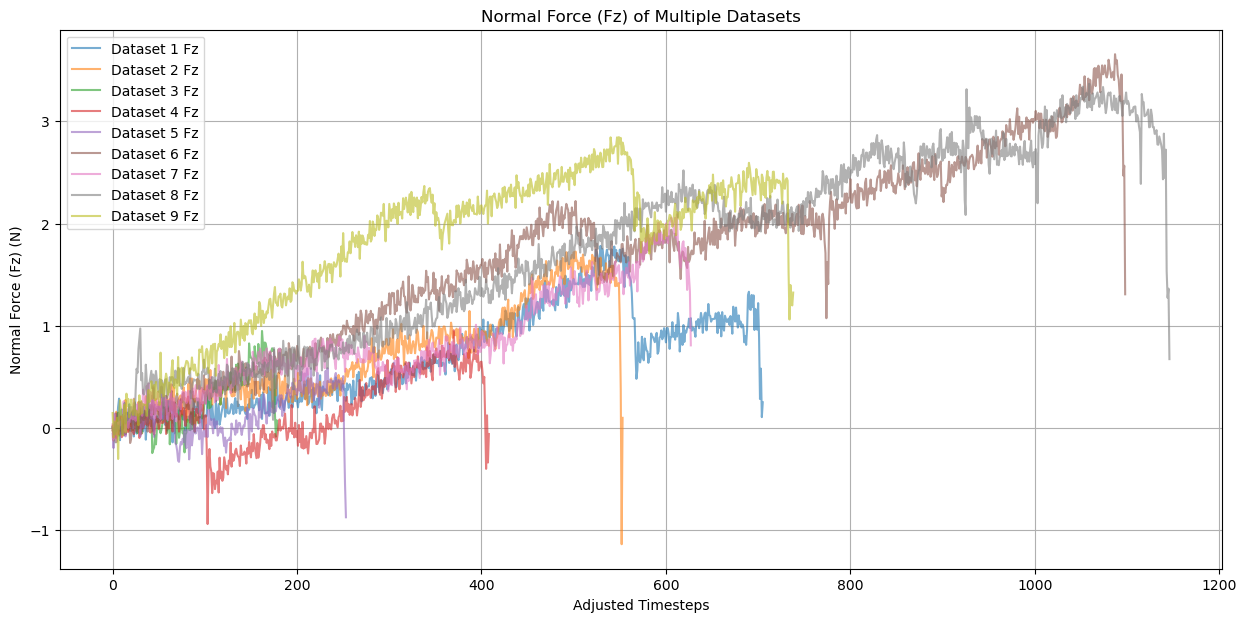

Average of maximum Fz forces: 1.9948820891203707
Standard deviation of maximum Fz forces: 1.0353282094687624
Average of average Fz forces: 0.8944958132652219
Standard deviation of average Fz forces: 0.652701631721835
Average of average Fx forces: 5.094876465121889
Standard deviation of average Fx forces: 0.3565019033379598


In [18]:
tests = [test_1, test_2, test_3, test_4, test_5, test_7, test_8, test_9, test_10]
ends = [end_1, end_2, end_3, end_4, end_5, end_7, end_8, end_9, end_10]
plot_multiple_tests(tests, ends)
calculate_statistics(tests, ends)

In [19]:
def save_tests_to_csv_cut(tests, ends, file_prefix="../raw_data/Gripper Test Microspines Angles//70//MatrixBrekzie_70"):
    # Save each test dataset to a separate CSV file, cutting at the end point
    for i, (test, end) in enumerate(zip(tests, ends)):
        test_cut = test.iloc[:end] if end is not None else test  # Cut the test data at the end point
        test_cut.to_csv(f'{file_prefix}_{i+1}.csv', index=False)

save_tests_to_csv_cut(tests, ends)